## EDA

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from itertools import combinations
import umap

In [54]:
data = pd.read_csv("D:/hcmus/s8/kltn/ICMR Datasets/data.csv")
labels = pd.read_csv("D:/hcmus/s8/kltn/ICMR Datasets/labels.csv")

In [55]:
df = pd.merge(data, labels)
df

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000,BRCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,sample_796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,BRCA
797,sample_797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,LUAD
798,sample_798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,COAD
799,sample_799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,PRAD


In [56]:
df["Unnamed: 0"] = df["Class"]
df = df.drop(columns = "Class")
df

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,PRAD,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
1,LUAD,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
2,PRAD,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
3,PRAD,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
4,BRCA,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,BRCA,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
797,LUAD,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
798,COAD,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
799,PRAD,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


In [57]:
df.isnull().sum()

Unnamed: 0    0
gene_0        0
gene_1        0
gene_2        0
gene_3        0
             ..
gene_20526    0
gene_20527    0
gene_20528    0
gene_20529    0
gene_20530    0
Length: 20532, dtype: int64

In [58]:
df['Unnamed: 0'].value_counts()

Unnamed: 0
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

In [59]:
df.describe()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.0,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,0.0,7.405509,0.499882,0.016744,0.013428,...,5.896573,8.765891,10.056252,4.847727,9.741987,11.742228,10.155271,9.590726,5.528177,0.095411
std,0.136850,1.200828,1.065601,0.638819,0.506537,0.0,1.108237,0.508799,0.133635,0.204722,...,0.746399,0.603176,0.379278,2.382728,0.533898,0.670371,0.580569,0.563849,2.073859,0.364529
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,...,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.299039,2.390365,6.303346,9.464466,0.0,6.676042,0.000000,0.000000,0.000000,...,5.454926,8.383834,9.826027,3.130750,9.400747,11.315857,9.836525,9.244219,4.092385,0.000000
50%,0.000000,3.143687,3.127006,6.655893,9.791599,0.0,7.450114,0.443076,0.000000,0.000000,...,5.972582,8.784144,10.066385,5.444935,9.784524,11.749802,10.191207,9.566511,5.218618,0.000000
75%,0.000000,3.883484,3.802534,7.038447,10.142324,0.0,8.121984,0.789354,0.000000,0.000000,...,6.411292,9.147136,10.299025,6.637412,10.082269,12.177852,10.578561,9.917888,6.876382,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,...,7.771054,11.105431,11.318243,9.207495,11.811632,13.715361,11.675653,12.813320,11.205836,5.254133


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), str(1)
memory usage: 125.5 MB


In [61]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Unnamed: 0'])

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_25808\556649069.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label_encoded'] = le.fit_transform(df['Unnamed: 0'])


In [62]:
df_numeric = df.select_dtypes(include='number')

In [63]:
df_numeric

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,label_encoded
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000,4
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000,3
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000,4
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000,4
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,0
797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,3
798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,1
799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,4


In [64]:
df.isnull().sum().sum()

np.int64(0)

In [65]:
df_numeric.var().sort_values()

gene_16790     0.000000
gene_16789     0.000000
gene_16788     0.000000
gene_16787     0.000000
gene_15141     0.000000
                ...    
gene_15589    31.325845
gene_15301    33.458776
gene_15898    34.503915
gene_9175     36.361940
gene_9176     44.763849
Length: 20532, dtype: float64

### chia X, Y

In [66]:
X = df.drop(['Unnamed: 0', 'label_encoded'], axis = 1)
Y_label = df['Unnamed: 0']

In [67]:
variance_threeshold = VarianceThreshold(threshold=0)
X_vth = variance_threeshold.fit_transform(X)

## Heatmap

In [68]:
top_genes = X.var().sort_values(ascending=False).head(50).index
heatmap_data = df[['Unnamed: 0'] + list(top_genes)].groupby('Unnamed: 0').mean()

In [69]:
heatmap_data

,gene_9176,gene_9175,gene_15898,gene_15301,gene_15589,gene_3540,gene_19661,gene_3541,gene_11250,gene_15897,...,gene_19153,gene_203,gene_4866,gene_440,gene_12995,gene_15899,gene_16342,gene_11388,gene_17905,gene_11249
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
BRCA,1.259048,1.616576,1.067688,0.412445,9.861198,6.739489,12.235694,9.000999,4.382483,2.899252,...,0.102399,4.749087,3.949640,9.129898,0.133401,0.201870,2.410850,4.462304,7.822391,3.409713
COAD,2.781059,1.054822,1.382390,6.596079,0.047390,16.251452,5.883456,14.480650,0.554094,4.308109,...,5.597128,6.023151,9.463895,8.405408,0.455645,0.103014,7.458125,2.650142,0.257899,9.166920
KIRC,0.409529,0.363720,1.078570,8.207115,0.565352,0.609368,6.227471,0.825130,0.320580,0.950528,...,10.922000,3.546398,5.674529,0.632945,1.848172,0.102937,13.312569,0.266646,1.221883,4.422819
LUAD,0.188861,0.867502,15.700952,5.959785,0.110857,12.131822,7.216909,14.267683,5.914015,13.639469,...,0.386087,6.742072,6.618296,8.813215,0.349441,10.385622,2.549555,1.809855,0.874683,10.742930
PRAD,18.237407,16.752995,0.742695,12.748019,0.167837,4.415432,1.319845,5.349038,13.641454,9.619839,...,0.335749,15.876616,14.240984,5.696159,11.485349,0.342966,4.169209,11.205210,0.594267,3.784524


<Figure size 1200x600 with 0 Axes>

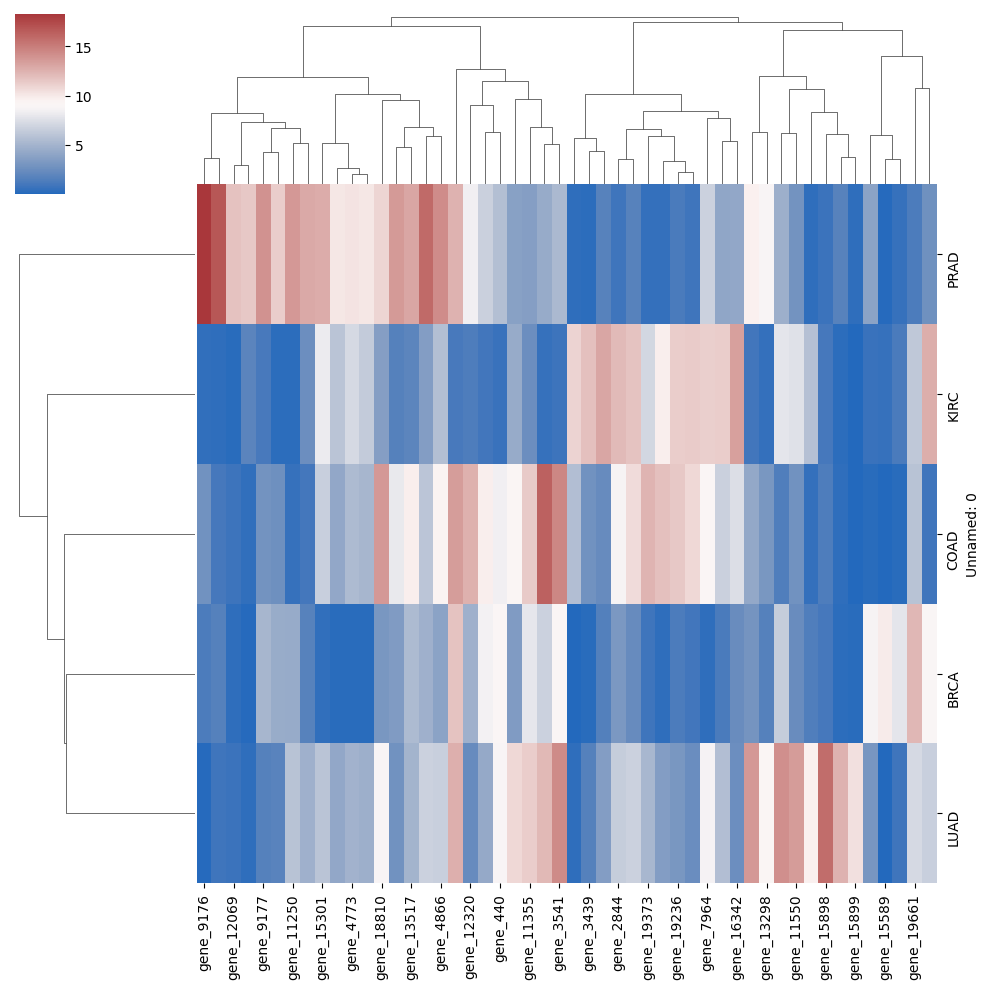

In [70]:
plt.figure(figsize=(12, 6))
sns.clustermap(heatmap_data, cmap = 'vlag')
plt.show()

# giảm chiều 

## PCA

In [71]:
scaler = StandardScaler()

In [72]:
X_vth_scaled = scaler.fit_transform(X_vth)

In [73]:
pca = PCA()
X_pca = pca.fit_transform(X_vth_scaled)

In [74]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

<function matplotlib.pyplot.show(close=None, block=None)>

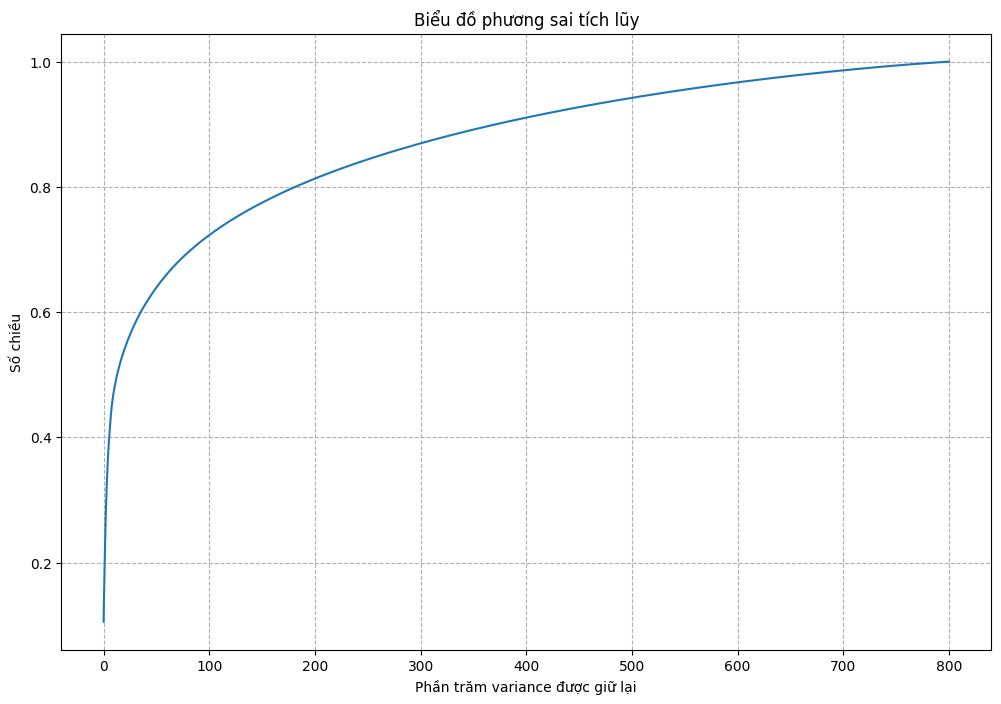

In [75]:
plt.figure(figsize=(12,8))
plt.plot(cum_var)
plt.grid(True, linestyle='--')
plt.ylabel('Số chiều')
plt.xlabel('Phần trăm variance được giữ lại')
plt.title('Biểu đồ phương sai tích lũy')
plt.show

In [76]:
le = LabelEncoder()
Y_encoded = le.fit_transform(Y_label)

In [77]:
pca_1 = PCA(n_components=350)
X_pca_1 = pca.fit_transform(X_vth_scaled)

## visualization pca

Text(0.5, 1.0, 'PCA visualization')

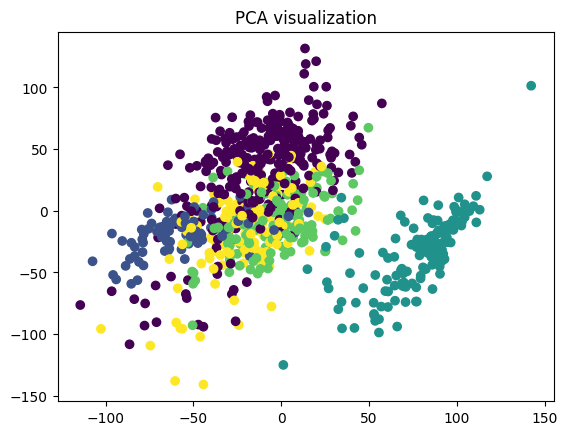

In [78]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_vth_scaled)

plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=Y_encoded)
plt.title("PCA visualization")

In [79]:
pca_10 = PCA(n_components = 6)
X_pca_10 = pca_10.fit_transform(X_vth_scaled)

In [80]:
pca_columns = [f'PC{i}' for i in range(1, 7)]
pca_df = pd.DataFrame(X_pca_10, columns = pca_columns)
pca_df['label'] = Y_label.values

In [81]:
pca_pairs = list(combinations(pca_columns, 2))

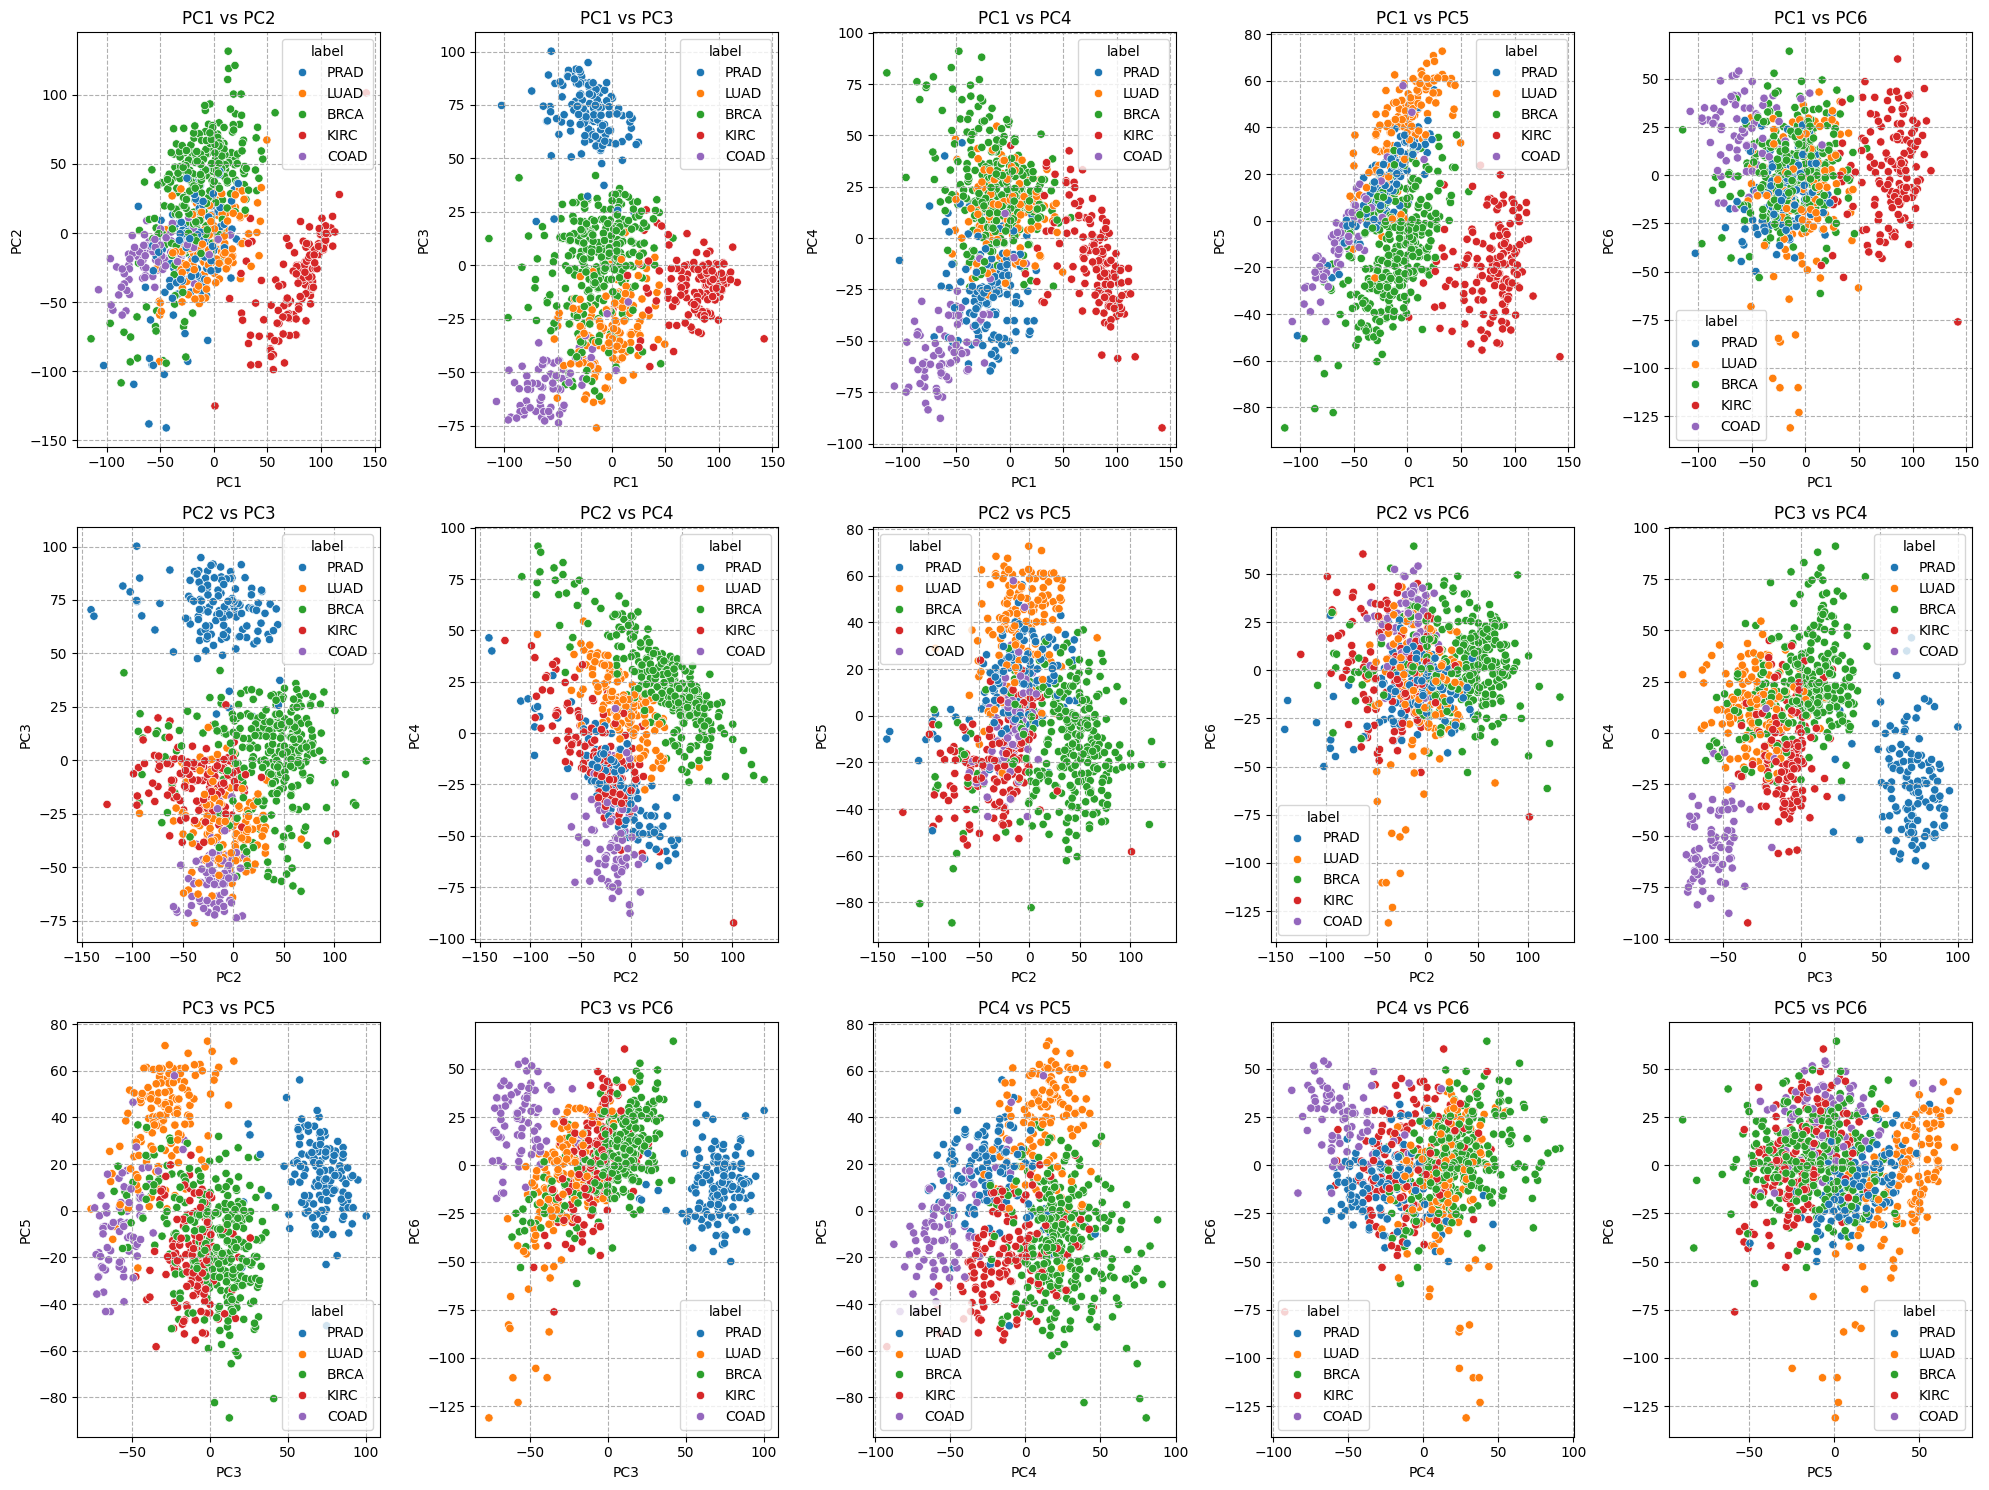

In [82]:
fig, axes = plt.subplots(nrows = 3, ncols = 5, figsize = (20, 15))
axes = axes.flatten()

for i, (pc1, pc2) in enumerate(pca_pairs):
    sns.scatterplot(
        data = pca_df,
        x = pc1,
        y = pc2,
        hue = 'label',
        ax = axes[i],
        legend = True,
        palette='tab10'
    )
    axes[i].set_title(f'{pc1} vs {pc2}')
    axes[i].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## t-SNE

In [83]:
tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate = 200,
    random_state = 42
)

X_tsne = tsne.fit_transform(X_vth)

In [84]:
tsne_df = pd.DataFrame(X_tsne, columns = ['TSNE1', 'TSNE2'])
tsne_df['label'] = Y_label.values

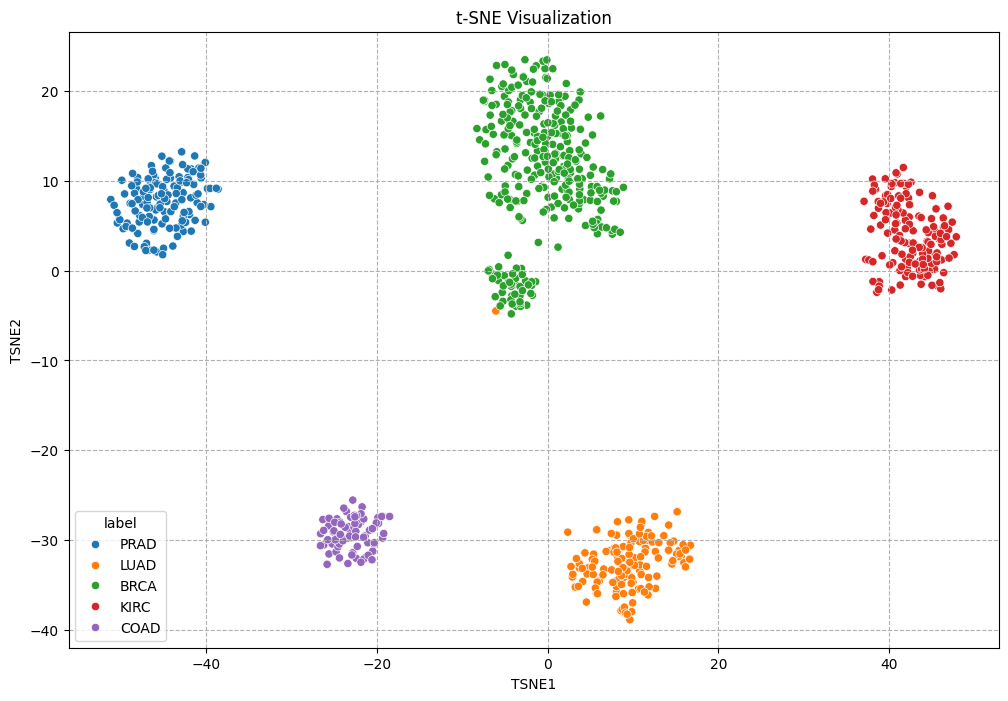

In [85]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = tsne_df,
    x = 'TSNE1',
    y = 'TSNE2',
    hue = 'label',
    palette = 'tab10',
)
plt.title("t-SNE Visualization")
plt.grid(True, linestyle='--')
plt.show()

## UMAP

In [86]:
umap_model = umap.UMAP(
    n_components = 2,
    n_neighbors = 5,
    min_dist = 0.1,
    random_state = 42
)

X_umap = umap_model.fit_transform(X_vth)

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [87]:
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df['label'] = Y_label.values

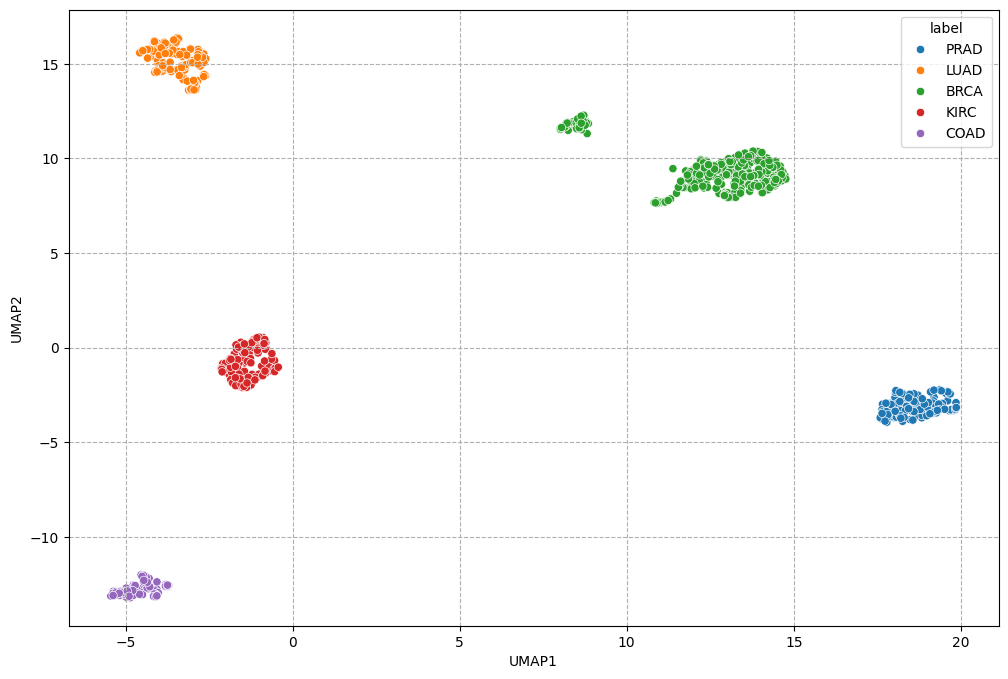

In [88]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = umap_df,
    x='UMAP1',
    y='UMAP2',
    hue = 'label',
    palette = 'tab10',
)
plt.grid(True, linestyle = '--')
plt.show()

In [89]:
X_pca_umap = umap_model.fit_transform(X_pca)

In [90]:
umap_df_1 = pd.DataFrame(X_pca_umap, columns=['UMAP1', 'UMAP2'])
umap_df_1['label'] = Y_label.values

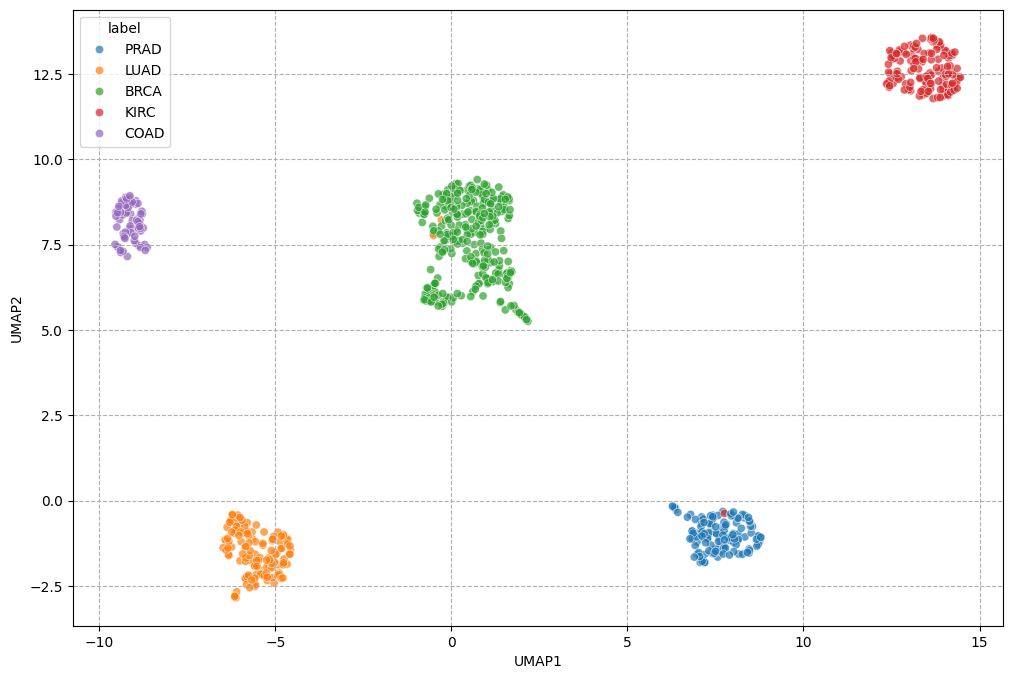

In [91]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=umap_df_1,
    x='UMAP1',
    y='UMAP2',
    hue='label',
    palette='tab10',
    alpha=0.7
)
plt.grid(True, linestyle='--')
plt.show()

# clustering

## K-means

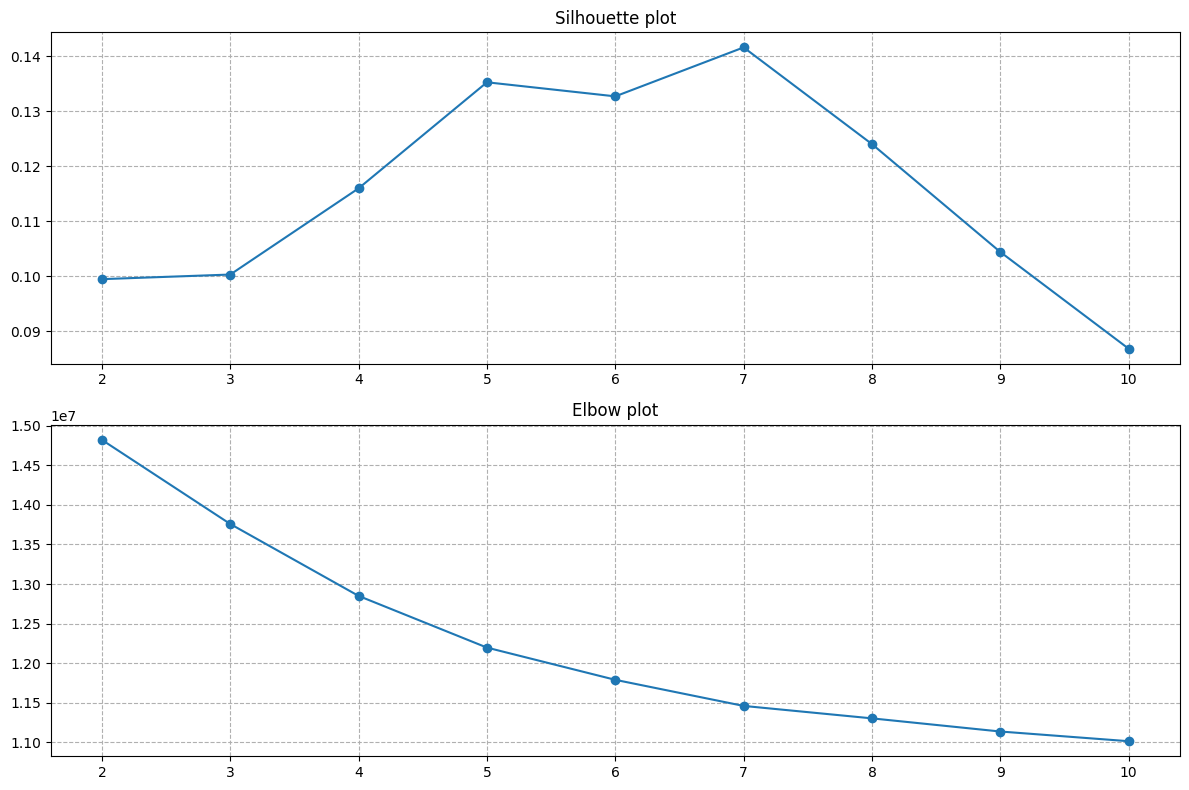

In [92]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    cluster_labels = kmeans.fit_predict(X_vth_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_vth_scaled, cluster_labels))

fig_1, axes_1 = plt.subplots(nrows = 2, ncols = 1, figsize = (12, 8))

axes_1[0].plot(list(k_values), sil_scores, marker = 'o')
axes_1[0].grid(True, linestyle = '--')
axes_1[0].set_title("Silhouette plot")
axes_1[1].plot(list(k_values), inertias, marker = 'o')
axes_1[1].grid(True, linestyle = '--')
axes_1[1].set_title("Elbow plot")

plt.tight_layout()
plt.show()

In [93]:
kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
cluster_labels = kmeans.fit_predict(X_vth_scaled)

In [ ]:
sil = silhouette_score(X_vth_scaled, cluster_labels)
ari = adjusted_rand_score(Y_label, cluster_labels)
nmi = normalized_mutual_info_score(Y_label, cluster_labels)

print("\n===== KMEANS RESULTS =====")
print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


===== KMEANS RESULTS =====
Number of clusters: 5
Silhouette Score: 0.1353
Adjusted Rand Index (ARI): 0.8001
Normalized Mutual Information (NMI): 0.8562



===== CROSSTAB: TRUE LABEL VS CLUSTER =====
Cluster      0    1    2   3    4
TrueLabel                        
0          249    0   51   0    0
1            0    0    4  74    0
2            0    0    2   0  144
3            2    0  139   0    0
4            1  134    1   0    0


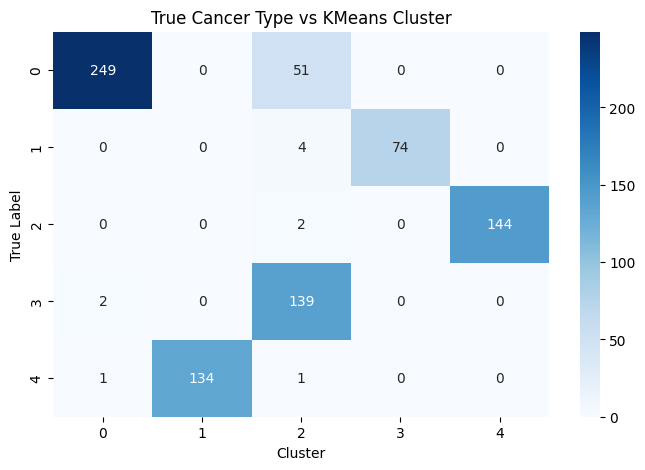

In [103]:
result_df = pd.DataFrame({
    'TrueLabel': Y_encoded,
    'Cluster': cluster_labels
})

cross_tab = pd.crosstab(result_df['TrueLabel'], result_df['Cluster'])
print("\n===== CROSSTAB: TRUE LABEL VS CLUSTER =====")
print(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("True Cancer Type vs KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

In [104]:
plot_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
plot_df['Cluster'] = cluster_labels
plot_df['TrueLabel'] = Y_encoded

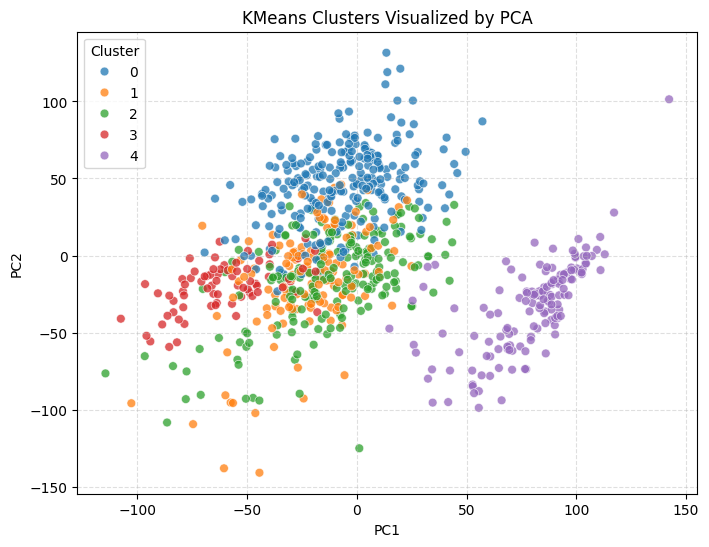

In [105]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("KMeans Clusters Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

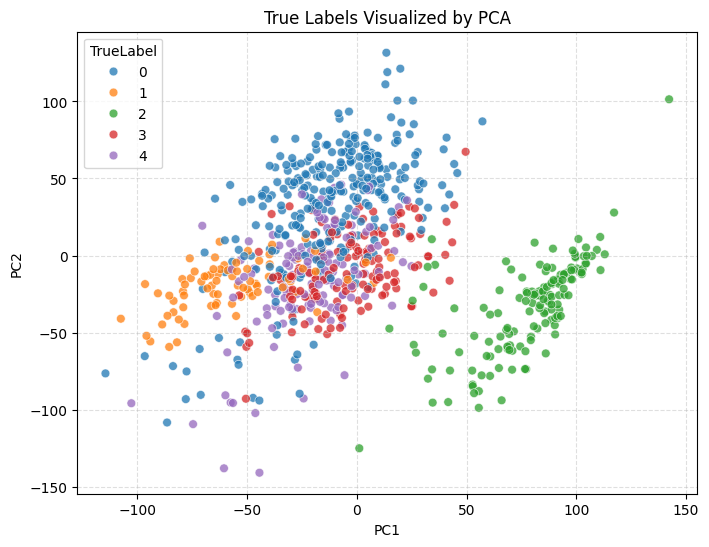

In [106]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='TrueLabel',
    palette='tab10',
    alpha=0.75,
    s=40
)
plt.title("True Labels Visualized by PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [116]:
df_kmeans = df.copy()
df_kmeans['kmeans_cluster'] = cluster_labels

print(df_kmeans[['Unnamed: 0', 'kmeans_cluster']].head())

  Unnamed: 0  kmeans_cluster
0       PRAD               1
1       LUAD               2
2       PRAD               1
3       PRAD               1
4       BRCA               0


## Hierarchical

## DBSCAN

## Gaussian mixture

## Spectral Clustering

# Classification

## Logistic Regression (baseline)

## SVM

## Random Forest

## XGBoost

## Neural Network